In [1]:
%pip install "pybamm==25.10.2" -q    # install PyBaMM if it is not installed #[plot,cite]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pybamm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.8/849.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.0/17.0 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.1/201.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 8.6 MB/s eta 0:00:00


In [2]:
#from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# import os
# os.chdir('/content/drive/MyDrive/Phd/Notes')

In [4]:
# import torch
# from torch.utils.data import Dataset, DataLoader

# 1. Setup DFN Model and Parameters

In [5]:
# Points for me: Need to recheck why,
# we chose asymmetric Butler-Volmer [Intercalation Kinematics] and reaction limited (asymmetric) [SEI].
# we cannot enable one-state hysteresis, and why should we have it?
# we cannot enable lithium plating: partially reversible, and why we need it?

model = pybamm.lithium_ion.DFN(options={
    "open-circuit potential": "single", # Cannot enable one-state hysteresis due to missing parameter problems in Pybamm.
    "intercalation kinetics": "symmetric Butler-Volmer",
    "thermal": "lumped",  # Without thermal lumping enabled, cell temperature will remain constant.
    "surface form": "algebraic",
    "surface temperature": "lumped",
    "SEI": "ec reaction limited", # Chosen to follow Tafel Law loosely
    "SEI film resistance": "distributed", # Chosen to follow Tafel Law loosely
    "SEI porosity change": "true", # Chosen to follow Tafel Law loosely
    "calculate discharge energy": "false", #default
    "cell geometry": "arbitrary", #default
    "calculate heat source for isothermal models": "false", #default
    "current collector": "uniform", #default
    "diffusivity": "single", #default
    "exchange-current density": "single", #default
    "lithium plating": "irreversible", # Cannot choose partially irreversible due to missing parameter problems in Pybamm.
    "lithium plating porosity change": "true",
    }
                               )

parameter_values = pybamm.ParameterValues("Mohtat2020") # Best options: Chen2020, Mohtat2020. Prada2013 does not have the right set of parameters for this experiment and hence avoided.
#print(parameter_values)

In [6]:
#model.print_parameter_info()

## 1.1 Add Missing Parameters

In [7]:
parameter_values.update(
    {
        # REQUIRED legacy parameter (dummy, not physically used)
        #"Negative electrode Butler-Volmer transfer coefficient": 0.5,
        #"Positive electrode Butler-Volmer transfer coefficient": 0.5,

        # REQUIRED for SEI reaction limited (asymmetric)
        #"SEI growth transfer coefficient": 0.9, # 0.22 # 0.05

        # Asymmetric Butler–Volmer parameters (actually used)
        #"Negative electrode anodic charge transfer coefficient": 0.5,
        #"Negative electrode cathodic charge transfer coefficient": 0.5,
        #"Positive electrode anodic charge transfer coefficient": 0.5,
        #"Positive electrode cathodic charge transfer coefficient": 0.5,

        # Thermal-lumped and surface temperature-lumped
        #"Cell thermal capacity [J.K-1]": 1200.0,
        "Casing heat capacity [J.K-1]": 300.0,
        "Environment thermal resistance [K.W-1]": 2.0,
        #"Internal thermal resistance [K.W-1]": 0.2,
    },
    check_already_exists=False
)

# 2. Setup Formation Experiment

### Multi-Stage formation

In [8]:
## Original Provided.
experiment_multi_A = pybamm.Experiment(
    [
        (
            "Rest for 1 hour",
            "Charge at 0.05C until 1.5V",
            "Rest for 1440 minutes",
            "Charge at 0.05C for 100 minutes",
            "Charge at 0.333C for 15 minutes",
            "Rest for 4320 minutes",
        ),
        (
            "Charge at 0.1C until 4.1V",
            "Discharge at 0.1C until 2.5V",
         ) * 4,
        (
            "Rest for 1 hour",
            "Charge at 0.05C until 4.1V",
            "Hold at 4.1V until C/20",
        ),

    ]
)

# more sub‑cycles at high SOC
## gentle nucleation below full voltage, then several moderate‑rate sub‑cycles at high SOC to grow/compact SEI, then a final soft CC‑CV
experiment_multi_B = pybamm.Experiment(
    [
        (
            "Rest for 2 hours",
            "Charge at 0.05C until 1.0V",
            "Rest for 1440 minutes",
            "Charge at 0.05C until 2.5V",
            "Rest for 720 minutes",
        ),
        (
            "Charge at 0.2C until 4.1V",
            "Hold at 4.1V until C/20",
            "Discharge at 0.1C until 3.2V",
        ) * 3,
        (
            "Charge at 0.1C until 4.1V",
            "Hold at 4.1V until C/30",
            "Rest for 720 minutes",
        ),
    ]
)

## low‑voltage pre‑cycling, then normal window
## first cycles in a narrower, lower‑voltage window, then expand to the full window after some SEI has formed.
experiment_multi_C = pybamm.Experiment(
    [
        (
            "Rest for 1 hour",
            "Charge at 0.05C until 3.6V",
            "Hold at 3.6V until C/50",
            "Rest for 720 minutes",
        ),
        (
            "Charge at 0.1C until 3.8V",
            "Discharge at 0.1C until 3.0V",
        ) * 2,
        (
            "Charge at 0.1C until 4.1V",
            "Hold at 4.1V until C/20",
            "Discharge at 0.1C until 2.7V",
        ) * 2,
        (
            "Rest for 4 hours",
        ),
    ]
)

## stepwise current increase
## classical “cycle 1 very slow, cycle 2 moderate, cycle 3 a bit faster” multi‑cycle formation, but all still ≤0.2C.
experiment_multi_D = pybamm.Experiment(
    [
        (
            "Rest for 2 hours",
            "Charge at 0.03C until 2.1V",
            "Rest for 1440 minutes",
        ),
        (
            "Charge at 0.05C until 4.1V",
            "Hold at 4.1V until C/30",
            "Discharge at 0.05C until 3.0V",
        ),
        (
            "Charge at 0.1C until 4.1V",
            "Hold at 4.1V until C/20",
            "Discharge at 0.1C until 2.7V",
        ),
        (
            "Charge at 0.2C until 4.1V",
            "Hold at 4.1V until C/10",
            "Discharge at 0.2C until 2.7V",
        ),
    ]
)

## high‑SOC pulsed conditioning
## low‑current pre‑charge close to full SOC, then several moderate‑rate pulses at high SOC, then a standard CC‑CV charge and mild discharge. Pulse currents are kept at 0.2C to avoid plating.
experiment_multi_E = pybamm.Experiment(
    [
        (
            "Rest for 1 hour",
            "Charge at 0.05C until 3.9V",
            "Hold at 3.9V until C/40",
            "Rest for 720 minutes",
        ),
        (
            "Charge at 0.2C for 20 minutes",
            "Rest for 40 minutes",
        ) * 4,
        (
            "Charge at 0.1C until 4.1V",
            "Hold at 4.1V until C/20",
            "Discharge at 0.1C until 2.7V",
        ),
        (
            "Rest for 4 hours",
        ),
    ]
)


### Slow Single-cycle Formation.

In [9]:
experiment_slow_single_1 = pybamm.Experiment(
    [
        (
            "Rest for 2 hours",
            "Charge at 0.05C until 4.1V",
            "Hold at 4.1V until C/30",
            "Discharge at 0.05C until 2.7V",
        ),
    ]
)


experiment_slow_single_2 = pybamm.Experiment(
    [
        (
            "Rest for 1 hour",
            "Charge at 0.05C until 3.8V",
            "Hold at 3.8V until C/40",
            "Charge at 0.05C until 4.1V",
            "Hold at 4.1V until C/30",
            "Discharge at 0.05C until 2.5V",
        ),
    ]
)

experiment_slow_single_3 = pybamm.Experiment(
    [
        (
            "Rest for 1 hour",
            "Charge at 0.1C until 4.1V",
            "Hold at 4.1V until C/20",
            "Rest for 720 minutes",
        ),
    ]
)

experiment_slow_single_4 = pybamm.Experiment(
    [
        (
            "Rest for 2 hours",
            "Charge at 0.1C until 4.0V",
            "Hold at 4.0V until C/30",
            "Discharge at 0.05C until 3.0V",
        ),
    ]
)

experiment_slow_single_5 = pybamm.Experiment(
    [
        (
            "Rest for 1 hours",
            "Charge at 0.05C until 3.8V",
            "Hold at 3.8V until C/40",
            "Discharge at 0.05C until 2.7V",
            "Rest for 30 minutes",
            "Charge at 0.1C until 4.1V",
            "Hold at 4.1V until C/30",
            "Discharge at 0.05C until 2.7V"
        ),
    ]
)


### Fast Single Cylce Formation

In [10]:
experiment_fast_single_1 = pybamm.Experiment(
    [
        (
            "Rest for 30 minutes",
            "Charge at 0.5C until 4.1V",
            "Hold at 4.1V until C/10",
            "Discharge at 0.2C until 2.7V",
        ),
    ]
)

experiment_fast_single_2 = pybamm.Experiment(
    [
        (
            "Rest for 30 minutes",
            "Charge at 0.7C until 4.1V",
            "Hold at 4.1V until C/10",
            "Discharge at 0.5C until 2.7V",
        ),
    ]
)

experiment_fast_single_3 = pybamm.Experiment(
    [
        (
            "Rest for 30 minutes",
            "Charge at 1.0C until 4.0V",
            "Hold at 4.0V until C/8",
            "Discharge at 0.5C until 2.7V",
        ),
    ]
)

experiment_fast_single_4 = pybamm.Experiment(
    [
        (
            "Rest for 30 minutes",
            "Charge at 0.8C until 3.9V",
            "Hold at 3.9V until C/8",
            "Charge at 0.5C until 4.1V",
            "Hold at 4.1V until C/10",
            "Discharge at 0.5C until 2.7V",
        ),
    ]
)

experiment_fast_single_5 = pybamm.Experiment(
    [
        (
            "Rest for 30 minutes",
            "Charge at 1.0C until 3.8V",
            "Hold at 3.8V until C/8",
            "Rest for 30 minutes",
            "Charge at 0.5C until 3.8V",
            "Hold at 3.8V until C/20",
            "Discharge at 0.5C until 2.7V",
        ),
    ]
)


In [11]:
solver = pybamm.IDAKLUSolver(rtol=1e-4,
                             atol=1e-6,
                             options={
                              #"dt_min": 1.0,
                              #"dt_max": 10.0,
                              "max_num_steps": 50000,
                             })
sim_formation = pybamm.Simulation(model, experiment=experiment_multi_A, parameter_values=parameter_values, solver = solver)
sol_formation = sim_formation.solve()

## 2.1 Formation Plots

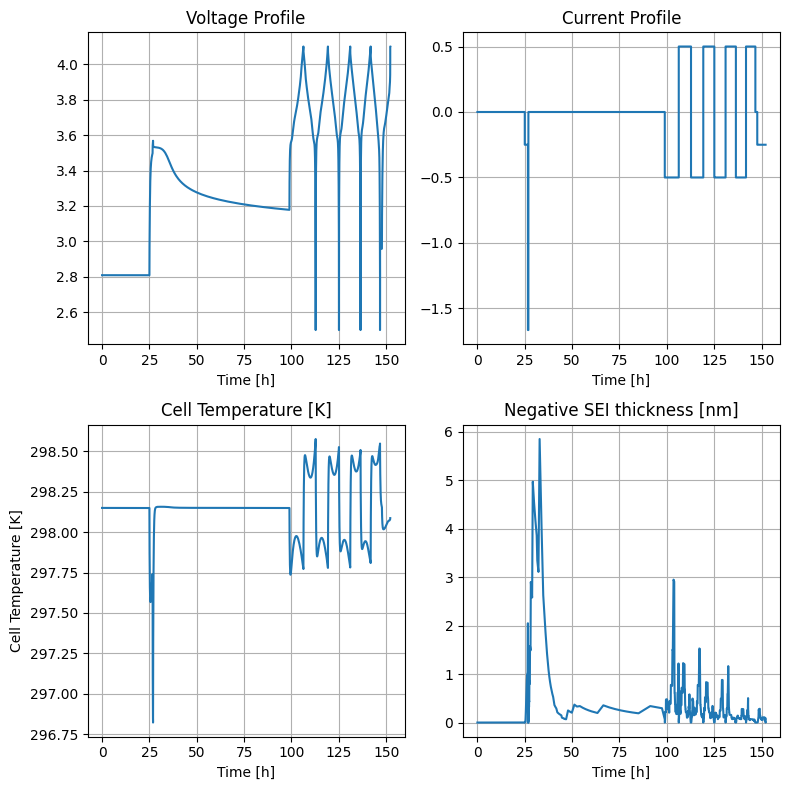

In [12]:
fig, ax = plt.subplots(2,2, figsize=(8,8))
ax[0,0].plot(sol_formation["Time [h]"].entries, sol_formation["Terminal voltage [V]"].entries)
ax[0,0].set_title("Voltage Profile")
ax[0,0].set_xlabel("Time [h]")
#ax[0,0].set_ylabel("Voltage [V]")
ax[0,0].grid()

ax[0,1].plot(sol_formation["Time [h]"].entries, sol_formation["Current [A]"].entries)
ax[0,1].set_title("Current Profile")
ax[0,1].set_xlabel("Time [h]")
#ax[0,1].set_ylabel("Current [A]")
ax[0,1].grid()


ax[1,0].plot(sol_formation["Time [h]"].entries, np.mean(sol_formation[ 'Cell temperature [K]'].entries,axis=0))
ax[1,0].set_title("Cell Temperature [K]")
ax[1,0].set_xlabel("Time [h]")
ax[1,0].set_ylabel("Cell Temperature [K]")
ax[1,0].grid()

sei_rate = np.diff(np.mean(sol_formation['Negative SEI thickness [m]'].entries,0)*1e9)
sei_rate = np.insert(sei_rate, 0, 0.0 )

ax[1,1].plot(sol_formation["Time [h]"].entries, sei_rate)
ax[1,1].set_title("Negative SEI thickness [nm]")
ax[1,1].set_xlabel("Time [h]")
#ax[1,1].set_ylabel("Negative SEI thickness [m]")
ax[1,1].grid()



plt.tight_layout()
#plt.grid(True)
plt.show()

In [ ]:
t_end = sol_formation.t[-1]
t_uniform = np.arange(0, t_end, 1)

In [ ]:
df2 = pd.DataFrame({
    "Time [s]": t_uniform,
    "Current [A]": sol_formation["Current [A]"](t_uniform),
    "Terminal voltage [V]": sol_formation["Terminal voltage [V]"](t_uniform),

    # For spatially-averaged variables (like Temperature or SEI),
    # PyBaMM's bracket notation sol["Var"](t) automatically handles the averaging
    # if it's a "Volume Averaged" variable.
    "Cell temperature [K]": sol_formation["Volume-averaged cell temperature [K]"](t_uniform),

    # SEI thickness is usually 2D (x, t); we take the average across the electrode
    "Negative SEI thickness [nm]": sol_formation["X-averaged negative SEI thickness [m]"](t_uniform) * 1e9,

    "Total lithium capacity [A.h]": sol_formation["Total lithium capacity [A.h]"](t_uniform),
})

In [ ]:
df2.to_csv("fast_1.csv")

In [ ]:
print(sol_formation.t.shape)
print(df2.shape)
print(sol_formation.t[-1])

(6604,)
(547689, 6)
547688.2847514305


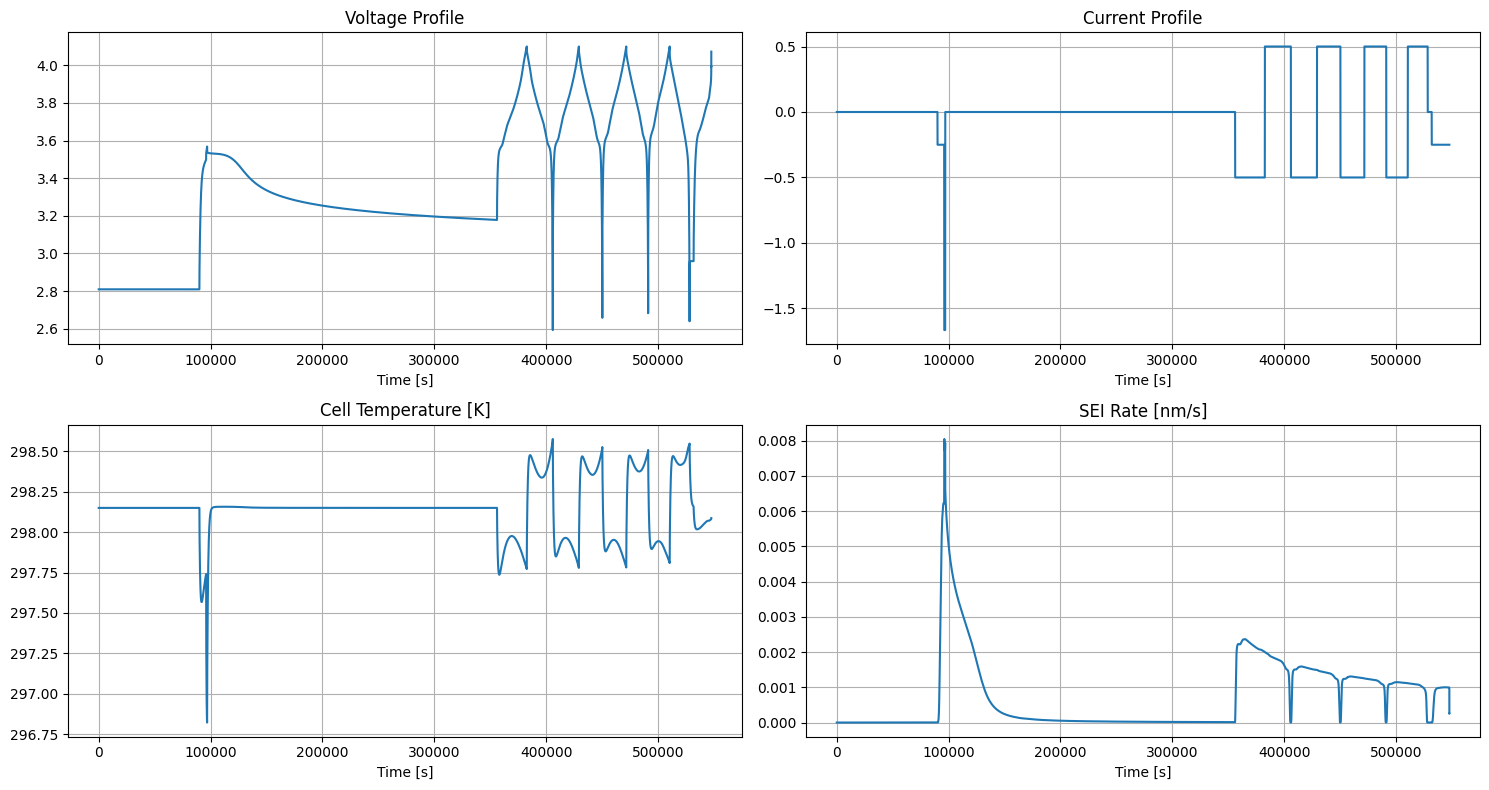

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(15,8))
ax[0,0].plot(df2["Time [s]"], df2["Terminal voltage [V]"])
ax[0,0].set_title("Voltage Profile")
ax[0,0].set_xlabel("Time [s]")
ax[0,0].grid()

ax[0,1].plot(df2["Time [s]"], df2["Current [A]"])
ax[0,1  ].set_title("Current Profile")
ax[0,1].set_xlabel("Time [s]")
ax[0,1].grid()

ax[1,0].plot(df2["Time [s]"], df2["Cell temperature [K]"])
ax[1,0].set_title("Cell Temperature [K]")
ax[1,0].set_xlabel("Time [s]")
ax[1,0].grid()

sei_rate = np.diff(df2["Negative SEI thickness [nm]"].values)
sei_rate = np.insert(sei_rate, 0, 0.0 )

ax[1,1].plot(df2["Time [s]"], sei_rate)
ax[1,1].set_title("SEI Rate [nm/s]")
ax[1,1].set_xlabel("Time [s]")
ax[1,1].grid()


plt.tight_layout()
#plt.grid(True)

plt.show()